# Input Parameters and Production System Description:

queue0 Event Log:
Time 0: Queue Sizes - Product 0: 1, Product 1: 0
Time 0: Queue Sizes - Product 0: 2, Product 1: 0
Time 0: Queue Sizes - Product 0: 3, Product 1: 0
Time 0: Queue Sizes - Product 0: 4, Product 1: 0
Time 0: Queue Sizes - Product 0: 5, Product 1: 0
Time 0: Queue Sizes - Product 0: 6, Product 1: 0
Time 0: Queue Sizes - Product 0: 7, Product 1: 0
Time 0: Queue Sizes - Product 0: 8, Product 1: 0
Time 0: Queue Sizes - Product 0: 9, Product 1: 0
Time 0: Queue Sizes - Product 0: 10, Product 1: 0
Time 0: Queue Sizes - Product 0: 11, Product 1: 0
Time 0: Queue Sizes - Product 0: 12, Product 1: 0
Time 0: Queue Sizes - Product 0: 13, Product 1: 0
Time 0: Queue Sizes - Product 0: 14, Product 1: 0
Time 0: Queue Sizes - Product 0: 15, Product 1: 0
Time 0: Queue Sizes - Product 0: 16, Product 1: 0
Time 0: Queue Sizes - Product 0: 17, Product 1: 0
Time 0: Queue Sizes - Product 0: 18, Product 1: 0
Time 0: Queue Sizes - Product 0: 19, Product 1: 0
Time 0: Queue Sizes - Product 0: 20, Prod

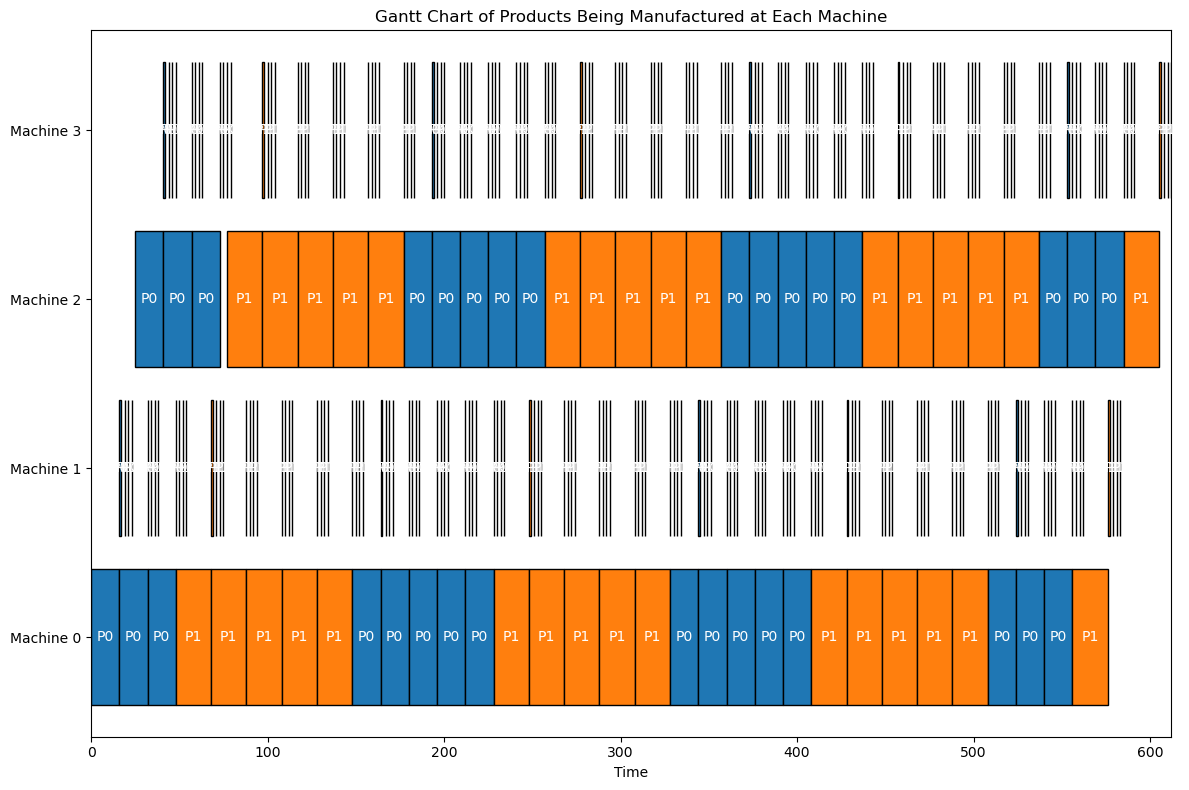

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import os

# Simulation Parameters
Total_Sim_Time = 672 * 1

# Machine Processing Times and Setups
Mac0_PT = [16, 20]
Mac1_PT = [2, 2]
Mac2_PT = [16, 20]
Mac3_PT = [2, 2]
Mac1_setups = {None: {0: 1, 1: 1}, 0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}}
Mac3_setups = {None: {0: 1, 1: 1}, 0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}}

# Product ID Mapping
product_id_mapping = {'Product 1': 0, 'Product 2': 1}

# Event Generation Functions
def generate_events_fixed(quantity, interval, time_period, product_id, event_type):
    num_events = time_period // interval
    times = [i * interval for i in range(num_events)]
    quantities = [quantity] * num_events
    return pd.DataFrame({'Time': times, 'Quantity': quantities, 'Product': product_id, 'Type': event_type})

def generate_events_random(num_events, time_period, max_quantity, product_id, event_type):
    times = sorted([random.randint(0, time_period) for _ in range(num_events)])
    quantities = [random.randint(1, max_quantity) for _ in range(num_events)]
    return pd.DataFrame({'Time': times, 'Quantity': quantities, 'Product': product_id, 'Type': event_type})

def simulate_events(time_period, product_settings):
    arrivals = []
    demands = []
    for config_name, settings in product_settings.items():
        product_name = ' '.join(config_name.split()[:-1])
        product_id = product_id_mapping[product_name]
        
        if settings['interval_type'] == 'fixed':
            df = generate_events_fixed(settings['quantity'], settings['interval'], time_period, product_id, settings['event_type'])
        else:
            num_events = random.randint(10, 20)
            df = generate_events_random(num_events, time_period, settings['max_quantity'], product_id, settings['event_type'])
        
        if settings['event_type'] == 'Arrival':
            arrivals.append(df)
        else:
            demands.append(df)
    
    arrivals_df = pd.concat(arrivals).sort_values('Time').reset_index(drop=True) if arrivals else pd.DataFrame()
    demands_df = pd.concat(demands).sort_values('Time').reset_index(drop=True) if demands else pd.DataFrame()
    return arrivals_df, demands_df

# Configuration for Product Events
product_settings = {
    'Product 1 Arrival': {'event_type': 'Arrival', 'interval_type': 'fixed', 'quantity': 64, 'interval': 672},
    'Product 2 Arrival': {'event_type': 'Arrival', 'interval_type': 'fixed', 'quantity': 64, 'interval': 672},
    'Product 1 Demand': {'event_type': 'Demand', 'interval_type': 'fixed', 'quantity': 64, 'interval': 672},
    'Product 2 Demand': {'event_type': 'Demand', 'interval_type': 'fixed', 'quantity': 64, 'interval': 672},
}

# Simulate Events
time_period = Total_Sim_Time
arrivals_df, demands_df = simulate_events(time_period, product_settings)

# Machine Classes
class BatchProcessingMachine:
    def __init__(self, processing_times, batch_size):
        self.processing_times = processing_times
        self.batch_size = batch_size
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        self.busy = True
        self.finish_time = current_time + self.processing_times[product]
        self.current_product = product
        self.event_log.append((self.current_product, current_time, self.finish_time, self.batch_size))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return False
    
    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Batch of Product {event[0]} processed from {event[1]} to {event[2]}")

class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        if self.current_product is not None:
            setup_time = self.setup_times[self.current_product][product]
        else:
            setup_time = self.setup_times[None][product]
        self.current_product = product
        start_time = current_time + setup_time
        self.finish_time = start_time + self.processing_times[product]
        self.busy = True
        self.event_log.append((product, current_time, start_time, self.finish_time))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return None

    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Product {event[0]} processed from {event[1]} to {event[3]}")

# Production Line Class
class ProductionLine:
    def __init__(self, batch_machine0_times, machine1_times, machine1_setups, batch_machine2_times, machine3_times, machine3_setups, arrivals_df, demands_df):
        self.machine0 = BatchProcessingMachine(batch_machine0_times, 4)
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = BatchProcessingMachine(batch_machine2_times, 4)
        self.machine3 = Machine(machine3_times, machine3_setups)
        self.arrivals_df = arrivals_df
        self.demands_df = demands_df
        self.queues = {'queue0': [[], []], 'queue1': [[], []], 'queue2': [[], []], 'queue3': [[], []], 'queue_fin': [[], []], 'demand': [[], []]}
        self.logs = {key: [] for key in self.queues}
        self.demand_met_log = []
        self.event_log = []
        self.total_demand = demands_df.groupby('Product')['Quantity'].sum()
        self.scoreP0 = 0
        self.scoreP1 = 0

    def add_item_to_queue(self, queue_name, product_name, current_time):
        if queue_name == 'queue_fin':
            if len(self.queues['demand'][product_name]) > 0:
                self.queues['demand'][product_name].pop(0)
                self.demand_met_log.append((product_name, current_time))
                queue_sizes = [len(q) for q in self.queues['demand']]
                self.logs['demand'].append((queue_sizes, current_time))
                self.log_current_state(current_time)
                return
        self.queues[queue_name][product_name].append(current_time)
        queue_sizes = [len(q) for q in self.queues[queue_name]]
        self.logs[queue_name].append((queue_sizes, current_time))

    def log_current_state(self, current_time):
        log_entry = {
            'Time': current_time,
            'Queue 0 Product 0': len(self.queues['queue0'][0]),
            'Queue 0 Product 1': len(self.queues['queue0'][1]),
            'Queue 1 Product 0': len(self.queues['queue1'][0]),
            'Queue 1 Product 1': len(self.queues['queue1'][1]),
            'Queue 2 Product 0': len(self.queues['queue2'][0]),
            'Queue 2 Product 1': len(self.queues['queue2'][1]),
            'Queue 3 Product 0': len(self.queues['queue3'][0]),
            'Queue 3 Product 1': len(self.queues['queue3'][1]),
            'Queue Fin Product 0': len(self.queues['queue_fin'][0]),
            'Queue Fin Product 1': len(self.queues['queue_fin'][1]),
            'Demand Queue Product 0': len(self.queues['demand'][0]),
            'Demand Queue Product 1': len(self.queues['demand'][1]),
            'Machine 0 Current Product': 'None' if self.machine0.current_product is None else self.machine0.current_product,
            'Machine 1 Current Product': 'None' if self.machine1.current_product is None else self.machine1.current_product,
            'Machine 2 Current Product': 'None' if self.machine2.current_product is None else self.machine2.current_product,
            'Machine 3 Current Product': 'None' if self.machine3.current_product is None else self.machine3.current_product,
            'Machine 0 timeremaining': 'None' if self.machine0.current_product is None else max(self.machine0.finish_time - current_time, 0),
            'Machine 1 timeremaining': 'None' if self.machine1.current_product is None else max(self.machine1.finish_time - current_time, 0),
            'Machine 2 timeremaining': 'None' if self.machine2.current_product is None else max(self.machine2.finish_time - current_time, 0),
            'Machine 3 timeremaining': 'None' if self.machine3.current_product is None else max(self.machine3.finish_time - current_time, 0),
            'Score_P0': round(self.scoreP0, 3),
            'Score_P1': round(self.scoreP1, 3),
        }
        self.event_log.append(log_entry)

    def remove_item_from_queue(self, queue_name, product_name, current_time):
        if self.queues[queue_name][product_name]:
            self.queues[queue_name][product_name].pop(0)
            queue_sizes = [len(q) for q in self.queues[queue_name]]
            self.logs[queue_name].append((queue_sizes, current_time))

    def run_step(self, current_time, totaltime):
        timeremainpct = (totaltime - current_time) / totaltime
        demandremainpct0 = len(self.queues['demand'][0]) / self.total_demand[0]
        demandremainpct1 = len(self.queues['demand'][1]) / self.total_demand[1]

        arrivals_this_step = self.arrivals_df[self.arrivals_df['Time'] == current_time]
        for _, row in arrivals_this_step.iterrows():
            for _ in range(row['Quantity']):
                self.add_item_to_queue('queue0', row['Product'], current_time)

        demand_this_step = self.demands_df[self.demands_df['Time'] == current_time]
        for _, row in demand_this_step.iterrows():
            for _ in range(row['Quantity']):
                self.add_item_to_queue('demand', row['Product'], current_time)

        for product_type in range(2):
            if current_time >= self.machine0.finish_time and self.machine0.busy:
                finished_product = self.machine0.update(current_time)
                for _ in range(self.machine0.batch_size):
                    self.add_item_to_queue('queue1', finished_product, current_time)
            avgdemrempct = (demandremainpct0 + demandremainpct1) / 2
            if len(self.queues['queue0'][0]) >= self.machine0.batch_size and len(self.queues['queue0'][1]) >= self.machine0.batch_size:
                produce = product_type if demandremainpct0 < avgdemrempct else 1 - product_type
            else:
                produce = 1
            while len(self.queues['queue0'][product_type]) >= self.machine0.batch_size and not self.machine0.busy and produce == 1:
                finish_time = self.machine0.process(product_type, current_time)
                for _ in range(self.machine0.batch_size):
                    self.remove_item_from_queue('queue0', product_type, current_time)

        for product_type in range(2):
            if current_time >= self.machine1.finish_time and self.machine1.busy:
                finished_product1 = self.machine1.update(current_time)
                if finished_product1 is not None:
                    self.add_item_to_queue('queue2', finished_product1, current_time)
            avgdemrempct = (demandremainpct0 + demandremainpct1) / 2
            if len(self.queues['queue1'][0]) > 0 and len(self.queues['queue1'][1]) > 0:
                produce = product_type if demandremainpct0 < avgdemrempct else 1 - product_type
            else:
                produce = 1
            if self.queues['queue1'][product_type] and not self.machine1.busy and produce == 1:
                self.remove_item_from_queue('queue1', product_type, current_time)
                self.machine1.process(product_type, current_time)

        for product_type in range(2):
            if current_time >= self.machine2.finish_time and self.machine2.busy:
                finished_product2 = self.machine2.update(current_time)
                for _ in range(self.machine2.batch_size):
                    self.add_item_to_queue('queue3', finished_product2, current_time)
            avgdemrempct = (demandremainpct0 + demandremainpct1) / 2
            if len(self.queues['queue2'][0]) >= self.machine2.batch_size and len(self.queues['queue2'][1]) >= self.machine2.batch_size:
                produce = product_type if demandremainpct0 < avgdemrempct else 1 - product_type
            else:
                produce = 1
            while len(self.queues['queue2'][product_type]) >= self.machine2.batch_size and not self.machine2.busy and produce == 1:
                finish_time = self.machine2.process(product_type, current_time)
                for _ in range(self.machine2.batch_size):
                    self.remove_item_from_queue('queue2', product_type, current_time)

        for product_type in range(2):
            if current_time >= self.machine3.finish_time and self.machine3.busy:
                finished_product3 = self.machine3.update(current_time)
                if finished_product3 is not None:
                    self.add_item_to_queue('queue_fin', finished_product3, current_time)
            avgdemrempct = (demandremainpct0 + demandremainpct1) / 2
            if len(self.queues['queue3'][0]) > 0 and len(self.queues['queue3'][1]) > 0:
                produce = product_type if demandremainpct0 < avgdemrempct else 1 - product_type
            else:
                produce = 1
            if self.queues['queue3'][product_type] and not self.machine3.busy and produce == 1:
                self.remove_item_from_queue('queue3', product_type, current_time)
                self.machine3.process(product_type, current_time)
        
        timeremainpct = (totaltime - current_time) / totaltime
        demandremainpct0 = len(self.queues['demand'][0]) / self.total_demand[0]
        demandremainpct1 = len(self.queues['demand'][1]) / self.total_demand[1]
        
        self.scoreP0 = timeremainpct - demandremainpct0
        self.scoreP1 = timeremainpct - demandremainpct1
        self.log_current_state(current_time)

    def print_demand_met_log(self):
        print("Demand Met Log:")
        for log in self.demand_met_log:
            print(f"Time {log[1]}: Demand for Product {log[0]} met")
    
    def print_logs(self):
        for key in self.queues:
            print(f"{key} Event Log:")
            for log in self.logs[key]:
                print(f"Time {log[1]}: Queue Sizes - Product 0: {log[0][0]}, Product 1: {log[0][1]}")

        print("\nMachine Logs:")
        machine_names = ['Machine 0', 'Machine 1', 'Machine 2', 'Machine 3']
        for i in range(4):
            machine = getattr(self, f'machine{i}')
            machine.print_event_log(machine_names[i])

        self.print_demand_met_log()

# Gantt Chart Functions
def extract_gantt_data(production_line):
    gantt_data = []
    for machine_name in ['machine0', 'machine1', 'machine2', 'machine3']:
        machine = getattr(production_line, machine_name)
        for event in machine.event_log:
            start_time = event[1]
            end_time = event[2]
            product = event[0]
            gantt_data.append({
                'Machine': machine_name,
                'Start': start_time,
                'Finish': end_time,
                'Product': product
            })
    return pd.DataFrame(gantt_data)

def plot_gantt_chart(gantt_df):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    machine_names = {
        'machine0': 'Machine 0',
        'machine1': 'Machine 1',
        'machine2': 'Machine 2',
        'machine3': 'Machine 3'
    }
    gantt_df['Machine'] = gantt_df['Machine'].map(machine_names)
    
    colors = {0: 'tab:blue', 1: 'tab:orange'}
    
    for i, row in gantt_df.iterrows():
        ax.barh(row['Machine'], row['Finish'] - row['Start'], left=row['Start'], color=colors[row['Product']], edgecolor='black')
        ax.text((row['Start'] + row['Finish']) / 2, row['Machine'], f'P{row["Product"]}', va='center', ha='center', color='white')
    
    ax.set_xlabel('Time')
    ax.set_title('Gantt Chart of Products Being Manufactured at Each Machine')
    ax.set_yticks(range(len(machine_names)))
    ax.set_yticklabels(machine_names.values())
    plt.tight_layout()
    plt.show()

# Run Simulation
production_line = ProductionLine(
    {0: Mac0_PT[0], 1: Mac0_PT[1]}, 
    {0: Mac1_PT[0], 1: Mac1_PT[1]}, 
    Mac1_setups,
    {0: Mac2_PT[0], 1: Mac2_PT[1]}, 
    {0: Mac3_PT[0], 1: Mac3_PT[1]}, 
    Mac3_setups, 
    arrivals_df,
    demands_df
)

totaltime = Total_Sim_Time
for current_time in range(totaltime):
    production_line.run_step(current_time, totaltime)
production_line.print_logs()

# Create Gantt Chart Data and Plot
gantt_df = extract_gantt_data(production_line)
plot_gantt_chart(gantt_df)

# Save Event Log to CSV
event_log_df = pd.DataFrame(production_line.event_log)
current_directory = os.getcwd()
new_folder = "output_data"
new_folder_path = os.path.join(current_directory, new_folder)

if not os.path.exists(new_folder_path):
    os.makedirs(new_folder_path)

file_name = "final_event_log_Exp2.csv"
file_path = os.path.join(new_folder_path, file_name)
event_log_df.to_csv(file_path, index=False)


# Generate demand and arrivals:

# Machine Class Initialization